c:\Users\3weee\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:48: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


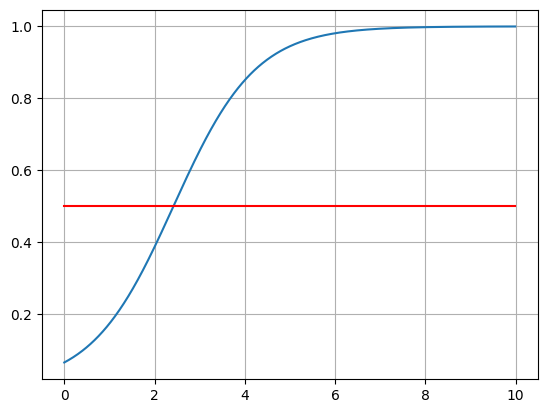

In [14]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim

class LogsitiRegression(nn.Module):
    def __init__(self):
        super(LogsitiRegression,self).__init__()
        self.linear = nn.Linear(1,1) 
    def forward(self,x):
        return torch.sigmoid(self.linear(x))

model = LogsitiRegression()

criterion = nn.BCELoss(size_average=False)
optimizer = optim.SGD(model.parameters())

x_data = torch.tensor([[1.0],[2.0],[3.0]])
y_data = torch.tensor([[0.0],[0.0],[1.0]])

for _ in range(10000):
    y_hat = model(x_data)
    loss = criterion(y_hat,y_data)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

x = torch.tensor(np.arange(0,10,0.01).reshape(1000,1),dtype=torch.float32)
y = model(x)

plt.plot(x.data.numpy(),y.data.numpy())
plt.plot(x.data.numpy(),[0.5]*1000,c="r")
plt.grid()
plt.show()